# **Exercise 1**

In [1]:
!pip install numpy
!pip install scipy
!pip install matplotlib
!pip install networkx


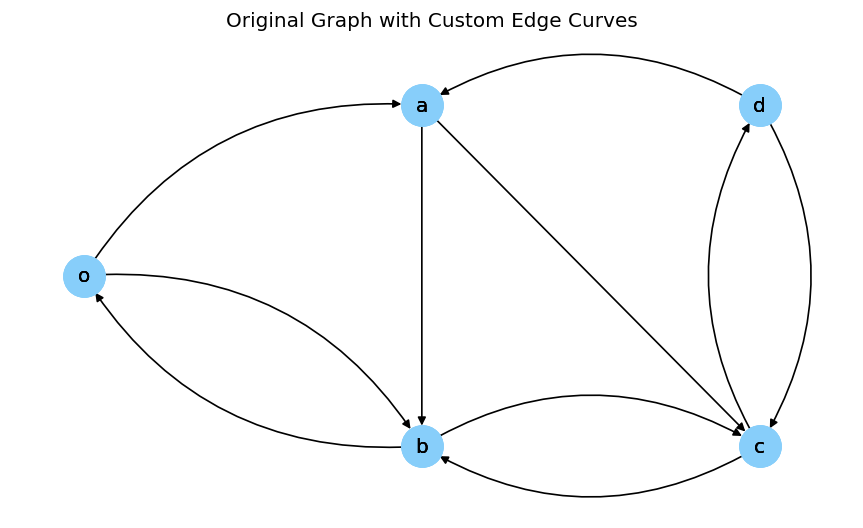

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define the nodes and their positions
nodes = ['o', 'a', 'b', 'c', 'd']
positions = [(0, 0.5), (0.5, 1), (0.5, 0), (1, 0), (1, 1)]
nodes_index = {node: i for i, node in enumerate(nodes)}
num_nodes = len(nodes)

# Define the edges
edges = [
    ('o', 'a'), ('o', 'b'), ('b', 'o'),
    ('a', 'b'), ('a', 'c'), ('b', 'c'),
    ('c', 'b'), ('d', 'a'), ('d', 'c'), ('c', 'd')
]

# Define the graph
G = nx.DiGraph()
G.add_edges_from(edges)
for index, name in enumerate(nodes):
    G.add_node(name, pos=positions[index])

# Define positions and edge styles
layout = dict((n, G.nodes[n]["pos"]) for n in G.nodes())
straight_edges = [('a', 'b'), ('a', 'c')]
curved_edges = list(set(G.edges()) - set(straight_edges))
arc_rad = -0.3  # Default for downward curve
specific_upward_edges = [('d', 'a')]  # Edges that should curve upward

# Visualize the graph with exact layout
def visualize_original_graph(graph):
    plt.figure(figsize=(7, 4), dpi=120)

    # Draw straight edges
    nx.draw(graph, pos=layout, with_labels=True, node_size=600, node_color='lightskyblue', edgelist=straight_edges)

    # Draw curved edges (downward)
    general_curved_edges = list(set(curved_edges) - set(specific_upward_edges))
    nx.draw(graph, pos=layout, with_labels=True, node_size=600, node_color='lightskyblue',
            edgelist=general_curved_edges, connectionstyle=f'arc3, rad={arc_rad}')

    # Draw specific upward curved edges
    nx.draw(graph, pos=layout, with_labels=True, node_size=600, node_color='lightskyblue',
            edgelist=specific_upward_edges, connectionstyle='arc3, rad=0.3')  # Upward curve

    plt.title("Original Graph with Custom Edge Curves")
    plt.show()

# Display the graph
visualize_original_graph(G)


In [3]:
# Define the Transition Rate Matrix (Lambda)
Lambda = np.array([
    [0, 2/5, 1/5, 0, 0],
    [0, 0, 3/4, 1/4, 0],
    [1/2, 0, 0, 1/3, 0],
    [0, 0, 1/3, 0, 2/3],
    [0, 1/3, 0, 1/3, 0]
])

print("Transition Rate Matrix (Lambda):\n", Lambda)

# Compute total rate of leaving each node (w)
w = np.sum(Lambda, axis=1)
print("\nTotal leaving rates (w):\n", w)

# Max rate (w_star)
w_star = np.max(w)
print("\nMaximum leaving rate (w_star):\n", w_star)

# Normalize the transition matrix (P)
P = Lambda / w[:, None]
print("\nNormalized Transition Matrix (P):\n", P)

# Compute the stochastic matrix (Q)
Q = Lambda / w_star
Q += np.diag(1 - np.sum(Q, axis=1))
print("\nStochastic Matrix (Q):\n", Q)

Transition Rate Matrix (Lambda):
 [[0.         0.4        0.2        0.         0.        ]
 [0.         0.         0.75       0.25       0.        ]
 [0.5        0.         0.         0.33333333 0.        ]
 [0.         0.         0.33333333 0.         0.66666667]
 [0.         0.33333333 0.         0.33333333 0.        ]]

Total leaving rates (w):
 [0.6        1.         0.83333333 1.         0.66666667]

Maximum leaving rate (w_star):
 1.0

Normalized Transition Matrix (P):
 [[0.         0.66666667 0.33333333 0.         0.        ]
 [0.         0.         0.75       0.25       0.        ]
 [0.6        0.         0.         0.4        0.        ]
 [0.         0.         0.33333333 0.         0.66666667]
 [0.         0.5        0.         0.5        0.        ]]

Stochastic Matrix (Q):
 [[0.4        0.4        0.2        0.         0.        ]
 [0.         0.         0.75       0.25       0.        ]
 [0.5        0.         0.16666667 0.33333333 0.        ]
 [0.         0.         0.33

# Question a

 What is, according to the simulations, the average time it takes a particle that starts in node a to leave the node and then return to it?

The average return time is estimated by simulating a random walk on the graph defined by
Λ. In each simulation, the particle starts at node
a, transition times are generated from an exponential distribution, and the next node is chosen according to the transition probabilities. The simulation continues until the particle returns to the starting node, and the total elapsed time is recorded. Repeating this procedure many times and averaging the results gives an estimate of the mean return time to node
a.

In [4]:
def simulate_random_walk(graph, start_node, end_node, num_simulations):
    nodes = list(graph.nodes())
    start_idx = nodes.index(start_node)
    end_idx = nodes.index(end_node)
    n_states = len(nodes)

    return_times = []

    for _ in range(num_simulations):
        pos = [start_idx]  # Start node
        transition_timestamps = 0
        while True:
            # Calculate next transition time
            t_next = -np.log(np.random.rand()) / w_star
            transition_timestamps += t_next

            # Determine next node based on probabilities in Q
            next_node = np.random.choice(range(n_states), p=Q[pos[-1]])
            pos.append(next_node)

            # Check if end node is reached
            if pos[-1] == end_idx and len(pos) > 1:
                return_times.append(transition_timestamps)
                break

    average_return_time = np.mean(return_times)
    return average_return_time


# Simulate random walk for return to 'a'
avg_return_time = simulate_random_walk(G, start_node='a', end_node='a',num_simulations=10000)
print(f"\nAverage return time to node 'a': {avg_return_time}")


Average return time to node 'a': 6.775618109415246


# Question b

 How does the result in a) compare to the theoretical return-time Ea[T+
a ]? (Include a descrip
tion of how this is computed.)

To compare the simulation results with theory, we compute the theoretical expected return
time to node $a$ using properties of continuous-time Markov chains. First, the stationary
distribution $\pi$ of the chain is obtained by computing the eigenvector of $Q^\top$
associated with the eigenvalue $1$ and normalizing it so that its entries sum to one.


Using the computed stationary distribution and leaving rate, the theoretical return time
to node $a$ is found to be approximately $6.71$. This value is very close to the average
return time obtained from simulations in part (a), which is approximately $6.75$. The small
difference between the two values is due to the finite number of simulations and the
randomness.












In [5]:
# Calculate the stationary distribution (pi_bar)
values, vectors = np.linalg.eig(Q.T)  # Eigenvalues and eigenvectors of Q^T
index = np.argmax(values.real)  # Dominant eigenvalue
pi_bar = vectors[:, index].real  # Corresponding eigenvector
pi_bar = pi_bar / np.sum(pi_bar)  # Normalize to get the stationary distribution

theoretical_return_time_a = 1 / (w[nodes_index['a']] * pi_bar[nodes_index['a']])

error_simulation = abs(avg_return_time - theoretical_return_time_a)

# Calculate the theoretical return time for node 'a'
print(f"Theoretical return time to node 'a': {theoretical_return_time_a}")
print("Difference between simulation and theory: ", error_simulation)


Theoretical return time to node 'a': 6.708333333333343
Difference between simulation and theory:  0.06728477608190353


# Question c

c) What is, according to the simulations, the average time it takes to move from node o to node
d?

In this section, we estimate the average time required for a particle to travel from node
o to node
d. The same simulation approach used in Section A is applied, with the starting node set to
o and the target node set to
d. By repeating the simulation many times and averaging the results, we obtain an estimate of the mean travel time between these two nodes.

In [6]:
# Simulation of average time from node 'o' to 'd'
average_time_o_to_d = simulate_random_walk(G,start_node='o', end_node='d', num_simulations=1000)
print("Average time from node 'o' to 'd': ", average_time_o_to_d)


Average time from node 'o' to 'd':  10.615761657679315


# Question d

d) How does the result in c) compare to the theoretical hitting-time Eo[Td]? (Describe also how
this is computed.)

In this section, we compute the theoretical hitting time from node
o to node
d. Using the same approach as in Section B, the transition matrix
P and the leaving rates
w are modified by removing the target node
d. This results in a reduced transition matrix
P
 and a corresponding vector of leaving rates w

In [7]:
# Calculate the hitting time from node 'o' to 'd'
def calculateHittingTimeOD():
    target_node = nodes_index['d']   # Node 'd'
    reachable_nodes = [node for node in range(num_nodes) if node != target_node]
    restricted_P = P[np.ix_(reachable_nodes, reachable_nodes)]
    restricted_w = w[np.ix_(reachable_nodes)]

    x_solution = np.linalg.solve(np.identity(num_nodes - 1) - restricted_P, np.ones(num_nodes - 1) / restricted_w)
    hitting_times_od = np.zeros(num_nodes)
    hitting_times_od[reachable_nodes] = x_solution

    return hitting_times_od[0]

# Obtain the hitting time and error
expected_hitting_time_od = calculateHittingTimeOD()
simulation_error = abs(average_time_o_to_d - expected_hitting_time_od)

print("Calculated hitting time (o to d): ", expected_hitting_time_od)
print("Simulation error: ", simulation_error)

Calculated hitting time (o to d):  10.766666666666666
Simulation error:  0.15090500898735115



## Question e

Interpret the matrix $\Lambda$ as the weight matrix of a graph $G = (V, E, \Lambda)$, and simulate the French- DeGroot dynamics on G with an arbitrary initial condition x(0). Does the dynamics converge to a consensus state for every initial condition x(0)?



***Solution***


The theory states that the dynamic converges to the consensus state if:
- its condensation graph has 1 sink;
- the sink component of the graph is aperiodic;


Let's check these conditions with the function : `can_reach_consensus`

In [8]:
# To check is consensus is reached
def can_reach_consensus(G):
    att_comp = list(nx.attracting_components(G))
    sink_comp = []
    for node in att_comp[0]:
        sink_comp.append(node)
    sink = G.subgraph(sink_comp)
    if nx.number_attracting_components(G) == 1 and nx.is_aperiodic(sink):
        print('The graph can  reach consensus')
    if nx.number_attracting_components(G) != 1:
        print('The condensation graph has more than one sink -> no consensus')
    if not nx.is_aperiodic(sink):
        print('The sink component of the graph is not aperiodic')

CG = nx.algorithms.components.condensation(G)
can_reach_consensus(G)

The graph can  reach consensus


And then here i am trying to show a simulation for being able to reach consensus condition using three different simulations

 # Experiment 1

Initial conditions: [0.69806198 0.22957531 0.77695404 0.70937064 0.9612268 ] 

Final opinions: [0.69418378 0.69450189 0.6950167  0.69398715 0.69482008] 

The consensus value is: 0.6945019225652623 



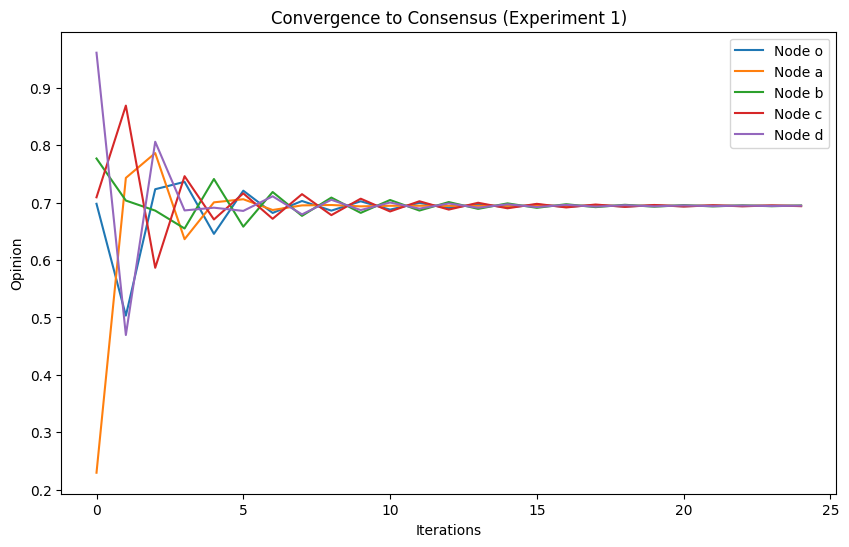

 # Experiment 2

Initial conditions: [0.62627443 0.33614387 0.49583196 0.13780666 0.1558347 ] 

Final opinions: [0.34069707 0.34079003 0.34094046 0.3406396  0.34088301] 

The consensus value is: 0.34079003291264887 



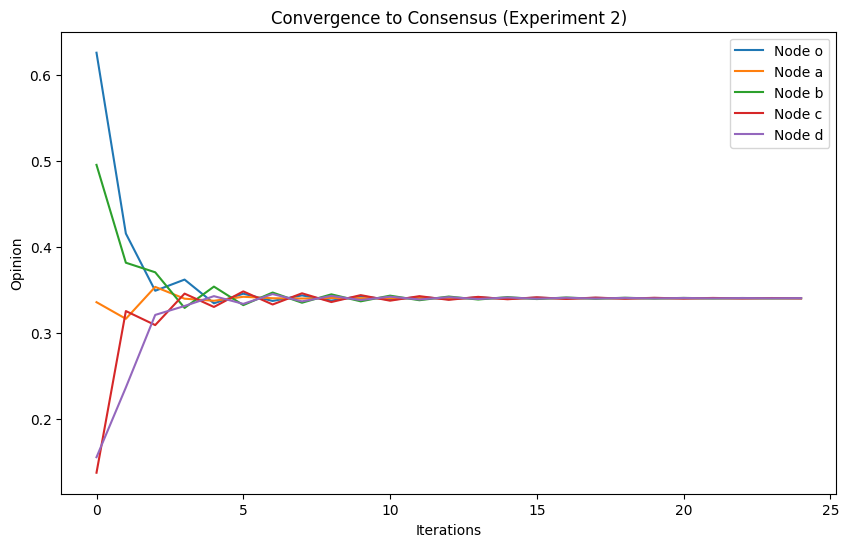

 # Experiment 3

Initial conditions: [0.99313558 0.23396937 0.04231842 0.1755541  0.34410578] 

Final opinions: [0.28744641 0.28670796 0.28551318 0.28790274 0.28596958] 

The consensus value is: 0.2867079679395633 



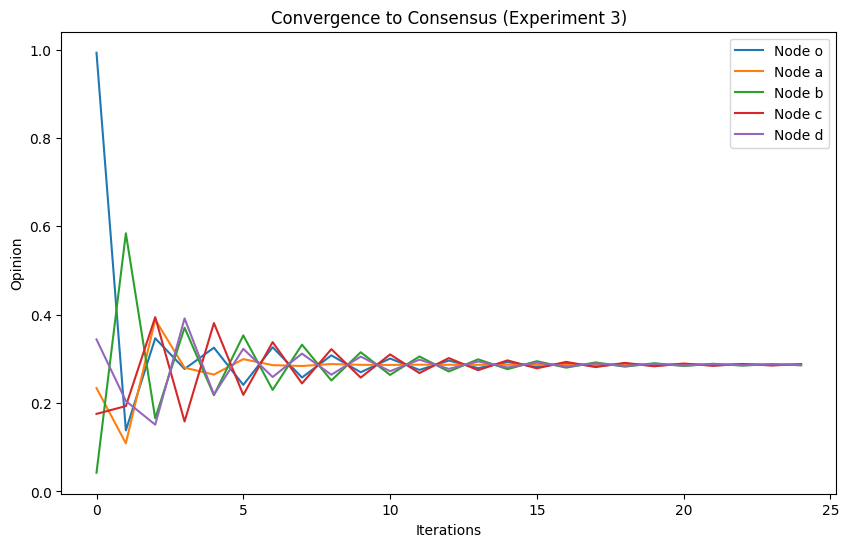

In [9]:

A = nx.adjacency_matrix(G)  # Get the adjacency matrix (sparse format)
A = A.toarray()             # Convert it to a dense NumPy array

# Compute the degree matrix (D) and transition probability matrix (P)
degrees = np.sum(A, axis=1)
D = np.diag(degrees)
P = np.linalg.inv(D) @ A  # Compute the stochastic matrix P

# Define parameters for the simulation
n_iter = 25  # Number of iterations for dynamics
n_times = 3  # Number of experiments/simulations
n_nodes = G.number_of_nodes()  # Number of nodes in the graph

# Create labels for plotting
labels = {node: node for node in G.nodes()}

# Perform the simulations
for i in range(n_times):
    # Initialize the opinion dynamics matrix
    x = np.zeros((n_nodes, n_iter))

    # Randomly initialize the opinions (input vector u)
    u = np.random.rand(n_nodes)  # Can be scaled (e.g., u = 10*np.random.rand(n_nodes))
    x[:, 0] = u
    x0 = x[:, 0]
    print(f" # Experiment {i+1}\n")
    print("Initial conditions:", x0, "\n")

    # Evolve the opinion vector over iterations
    for t in range(1, n_iter):
        x[:, t] = P @ x[:, t - 1]
    x_final = x[:, n_iter - 1]
    print("Final opinions:", x_final, "\n")

    # Compute the stationary distribution (eigenvector of eigenvalue 1)
    w, v = np.linalg.eig(P.T)  # Eigenvalues and eigenvectors of P^T
    for index in [i for i in range(len(G)) if np.isclose(w[i], 1)]:
        pi = v[:, index].real  # Convert eigenvector to real if needed
        pi = pi / np.sum(pi)   # Normalize the eigenvector

    # The consensus value is linked to the initial conditions by pi.T @ x0
    consensus_value = pi.T @ x0
    print("The consensus value is:", consensus_value, "\n")

    # Plot the convergence of opinions for all nodes
    plt.figure(figsize=(10, 6))
    for node in range(n_nodes):
        trajectory = x[node, :]
        plt.plot(trajectory, label=f'Node {list(G.nodes())[node]}')

    plt.legend()
    plt.title(f"Convergence to Consensus (Experiment {i+1})")
    plt.xlabel('Iterations')
    plt.ylabel('Opinion')
    plt.show()


Since the graph is strongly connected and aperiodic, all opinions converge to a common value. So $x(t)$ converges to a consensus status for every initial condition $x(0)$.

## Question f
Assume that the initial state of the dynamics for each node $i \in V$ is given by $x_i(0) = \xi_{i}$ , where ${\xi_{i}}_{i \in V}$ are independent random variables with variance:
$ \quad σ_a^2 = σ_b^2 = σ_c^2 = 2, \quad σ_o^2=σ_d^2 =1$

**Compute the variance of the consensus value, and compare your results with numerical simulations.**



The theoretical value of the variance is given by -->
$
 {Var}(\bar{x}) = \sum_{i} \sigma^2_i \pi_i^2
$.


In [10]:
w, v = np.linalg.eig(P.T)

# Select the eigenvalue 1 and print the eigenvector
for index in [i for i in range(len(G)) if np.isclose(w[i], 1)]:
    pi = v[:, index].real  # Eigenvectors are complex, convert to real
    pi = pi / np.sum(pi)   # Normalize the eigenvector

# Set the variances based on the given requirements
variance = np.array([1, 2, 2, 2, 1])  # Variance for nodes o, a, b, c, d

# Compute the theoretical variance of the consensus value
theoretical_variance = np.sum(variance * (pi ** 2))
print("Theoretical variance of the consensus value:", theoretical_variance)

# Start with random initial states and run the dynamics 200 times
# Store in alfa_err the consensus values at each run
alfa_err = np.zeros(200)

for i in range(200):
    # x0: Random initial states with the specified variances
    x = np.random.normal(scale=np.sqrt(variance), size=len(variance))
    for n in range(500):  # Simulate dynamics
        x = P @ x # this is the dynamics we used to have french-degroot
    # Store the consensus value for this run
    alfa_err[i] = (np.mean(x)) ** 2

# Compute the numerical variance from the simulations
simulated_variance = np.mean(alfa_err)
print("Variance of the numerical simulation:", simulated_variance)


Theoretical variance of the consensus value: 0.4081632653061225
Variance of the numerical simulation: 0.39521646486482653


## Question G
Remove the edges $(d, a)$ ,$(d, c)$,$(a, c)$ and $(b, c)$
**Describe and motivate the asymptotic behaviour of the dynamics. If the dynamics converges to a asymptotic state, how is such a state related to the initial condition** $x(0)$?

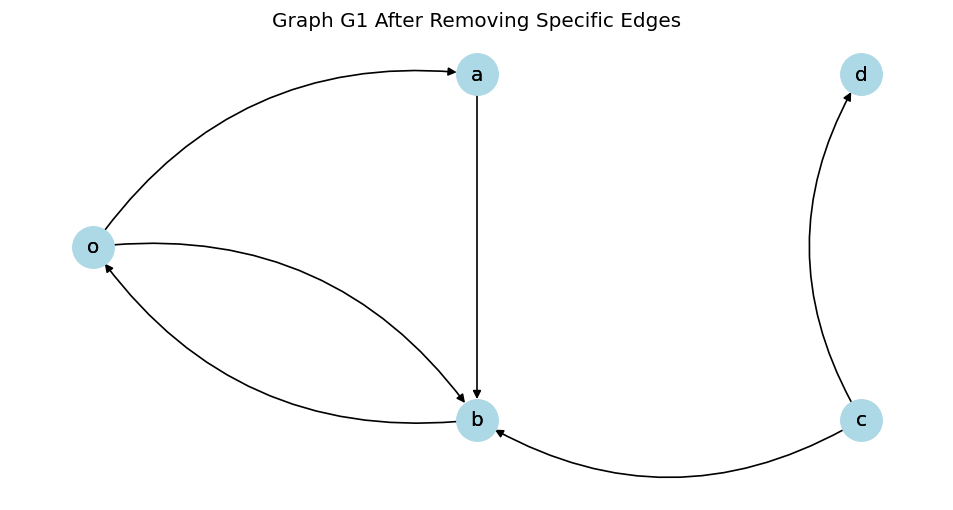

The number of components in the condensation graph is: 3
The condensation graph has more than one sink -> no consensus


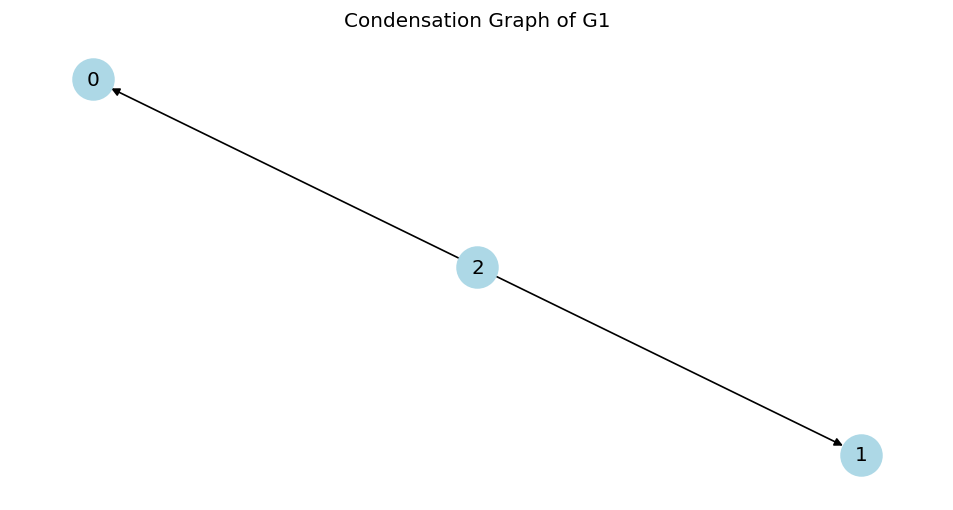

In [11]:
# Update the edges by removing specific edges
nodes = ['o', 'a', 'b', 'c', 'd']
positions = [(0, 0.5), (0.5, 1), (0.5, 0), (1, 0), (1, 1)]
edges = set(G.edges()) - set([('d', 'a'), ('d', 'c'), ('a', 'c'), ('b', 'c')])

# Create the new graph G1
G1 = nx.DiGraph()
G1.add_edges_from(edges)
for index, name in enumerate(nodes):
    G1.add_node(name, pos=positions[index])

# Define the layout for visualization
layout = dict((n, G1.nodes[n]["pos"]) for n in G.nodes())

# Define straight and curved edges
straight_edges = [('a', 'b')]
curved_edges = list(set(G1.edges()) - set(straight_edges))

arc_rad = -0.3  # Default downward curve

# Visualize the new graph G1
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# Draw straight edges
nx.draw(G1, pos=layout, with_labels=True, node_size=600, node_color='lightblue', edgelist=straight_edges)

# Draw curved edges
nx.draw(G1, pos=layout, with_labels=True, node_size=600, node_color='lightblue', edgelist=curved_edges, connectionstyle=f'arc3, rad = {arc_rad}')

plt.title("Graph G1 After Removing Specific Edges")
plt.show()

# Analyze the condensed graph (strongly connected components)
CG1 = nx.condensation(G1)

print('The number of components in the condensation graph is:', len(CG1.nodes()))

# Use the defined consensus function to check properties of G1
can_reach_consensus(G1)

# Visualize the condensation graph
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
nx.draw(CG1, with_labels=True, node_size=600, node_color='lightblue')
plt.title("Condensation Graph of G1")
plt.show()

 # Experiment 1

Initial conditions: [0.20048545 0.03061374 0.14204454 0.65600042 0.99516217] 

Final opinions (asymptotic state): [0.14313474 0.14313474 0.14313474 0.56914846 0.99516217] 

Number of unit eigenvalues: 2
Unit eigenvalues: [np.complex128(1+0j), np.complex128(1+0j)]

Predicted asymptotic state (from P1^t @ x0): [0.14313474 0.14313474 0.14313474 0.56914846 0.99516217] 



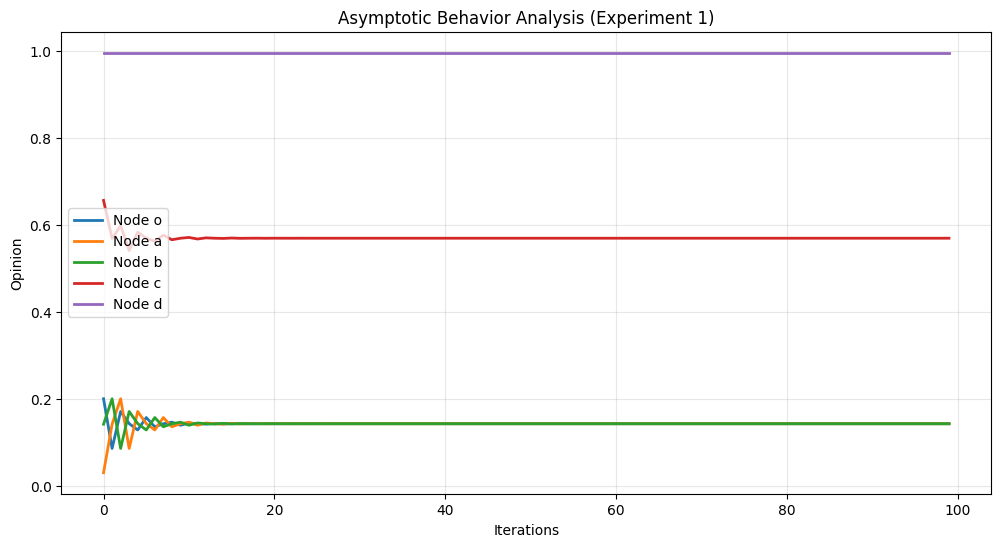

 # Experiment 2

Initial conditions: [0.81052165 0.7698482  0.49423271 0.64931569 0.91174466] 

Final opinions (asymptotic state): [0.67587139 0.67587139 0.67587139 0.79380802 0.91174466] 

Number of unit eigenvalues: 2
Unit eigenvalues: [np.complex128(1+0j), np.complex128(1+0j)]

Predicted asymptotic state (from P1^t @ x0): [0.67587139 0.67587139 0.67587139 0.79380802 0.91174466] 



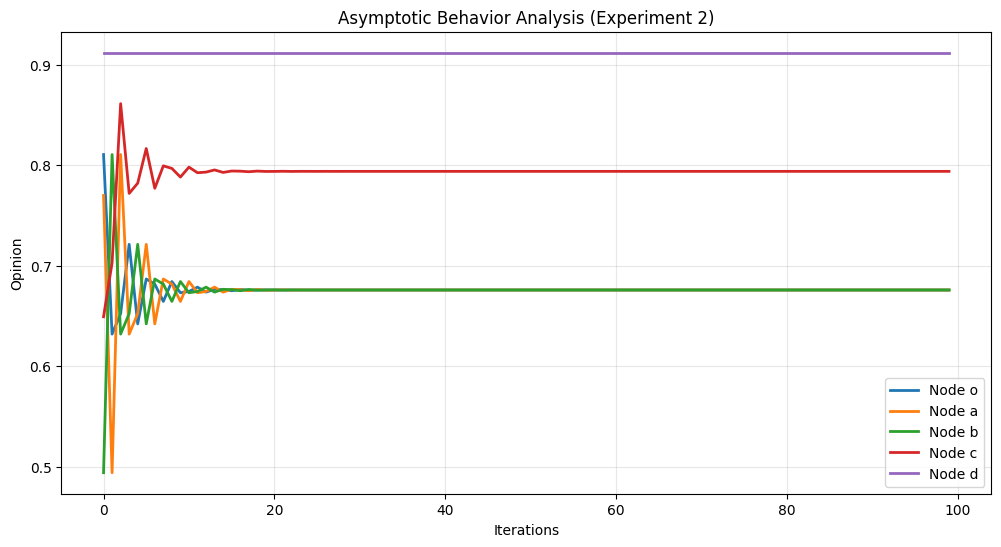

 # Experiment 3

Initial conditions: [0.8162434  0.83787846 0.67152851 0.67653171 0.67914498] 

Final opinions (asymptotic state): [0.76268446 0.76268446 0.76268446 0.72091472 0.67914498] 

Number of unit eigenvalues: 2
Unit eigenvalues: [np.complex128(1+0j), np.complex128(1+0j)]

Predicted asymptotic state (from P1^t @ x0): [0.76268446 0.76268446 0.76268446 0.72091472 0.67914498] 



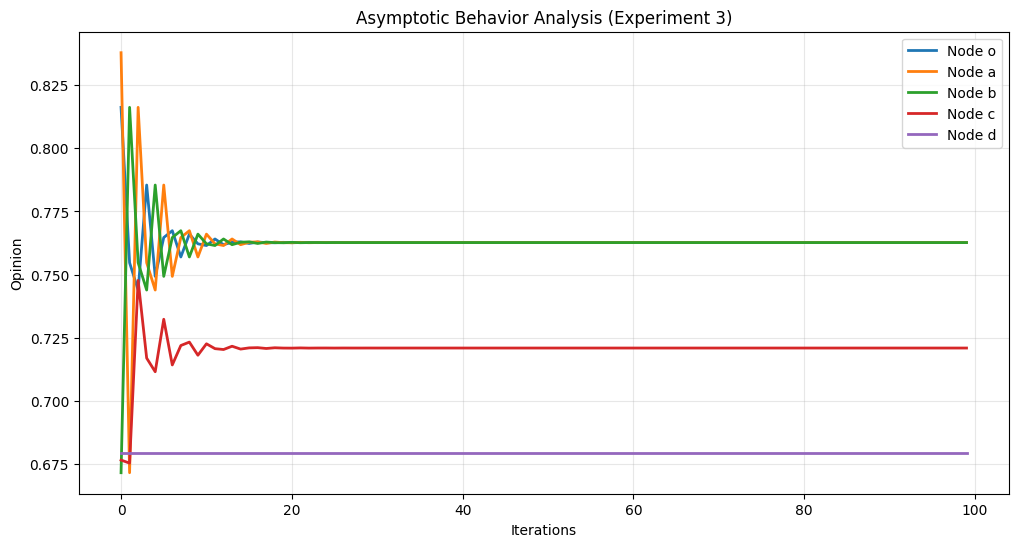

ANALYSIS: Relationship between x(0) and asymptotic state

Comparing experiments:

Experiment 1:
  Initial condition: [0.20048545 0.03061374 0.14204454 0.65600042 0.99516217]
  Asymptotic state: [0.14313474 0.14313474 0.14313474 0.56914846 0.99516217]
  Relationship error: 0.000000

Experiment 2:
  Initial condition: [0.81052165 0.7698482  0.49423271 0.64931569 0.91174466]
  Asymptotic state: [0.67587139 0.67587139 0.67587139 0.79380802 0.91174466]
  Relationship error: 0.000000

Experiment 3:
  Initial condition: [0.8162434  0.83787846 0.67152851 0.67653171 0.67914498]
  Asymptotic state: [0.76268446 0.76268446 0.76268446 0.72091472 0.67914498]
  Relationship error: 0.000000

Convergence Analysis:

Does the dynamics converge to a single asymptotic state?
Final states across experiments show:
  Experiment 1: [0.14313474 0.14313474 0.14313474 0.56914846 0.99516217]
  Experiment 2: [0.67587139 0.67587139 0.67587139 0.79380802 0.91174466]
  Experiment 3: [0.76268446 0.76268446 0.76268446 0

In [12]:
# Compute the degree matrix (D1) and transition probability matrix (P1)
A1 = nx.adjacency_matrix(G1, nodelist=nodes)  # Get the adjacency matrix (sparse format), specifying nodelist
A1 = A1.toarray()             # Convert it to a dense NumPy array
degrees1 = np.sum(A1, axis=1)
D1 = np.diag(degrees1)

# Handle nodes with no outgoing edges (degrees1 == 0)
# Replace zero entries in the degree matrix with 1 to avoid singularity
rows_with_zero_degree = np.where(degrees1 == 0)[0]
for i in rows_with_zero_degree:
    A1[i, i] = 1          # Add self-loop to Adjacency
    degrees1[i] = 1       # Update degree to 1

D1 = np.diag(degrees1)
P1 = np.linalg.inv(D1) @ A1

# Define parameters for the simulation - use more iterations to observe asymptotic behavior
n_iter = 100  # Increased iterations to better observe asymptotic behavior
n_times = 3  # Number of experiments/simulations
n_nodes = G1.number_of_nodes()  # Number of nodes in the graph

# Store results for analysis
all_initial_conditions = []
all_final_states = []
all_relationships = []

# Perform the simulations
for i in range(n_times):
    # Initialize the opinion dynamics matrix
    x = np.zeros((n_nodes, n_iter))

    # Randomly initialize the opinions (input vector u)
    u = np.random.rand(n_nodes)  # Can be scaled (e.g., u = 10*np.random.rand(n_nodes))
    x[:, 0] = u
    x0 = x[:, 0].copy()
    all_initial_conditions.append(x0.copy())

    print(f" # Experiment {i+1}\n")
    print("Initial conditions:", x0, "\n")

    # Evolve the opinion vector over iterations
    for t in range(1, n_iter):
        x[:, t] = P1 @ x[:, t - 1]

    x_final = x[:, n_iter - 1]
    all_final_states.append(x_final.copy())
    print("Final opinions (asymptotic state):", x_final, "\n")

    # Analyze the relationship between initial condition and asymptotic state
    # Compute the limit of P1^t as t -> infinity
    # Find eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(P1.T)

    # Find all eigenvalues with magnitude close to 1 (for periodic/asymptotic behavior)
    unit_eigenvalues = []
    unit_eigenvectors = []
    for idx, eigval in enumerate(eigenvalues):
        if np.isclose(np.abs(eigval), 1.0, atol=1e-6):
            unit_eigenvalues.append(eigval)
            unit_eigenvectors.append(eigenvectors[:, idx].real)

    print(f"Number of unit eigenvalues: {len(unit_eigenvalues)}")
    print(f"Unit eigenvalues: {[np.round(e, 4) for e in unit_eigenvalues]}\n")

    # Compute the relationship: asymptotic state as a function of initial condition
    # For convergence, we need to check if P1^t converges
    P1_power = np.linalg.matrix_power(P1, n_iter)
    asymptotic_matrix = P1_power
    predicted_asymptotic = asymptotic_matrix @ x0
    print("Predicted asymptotic state (from P1^t @ x0):", predicted_asymptotic, "\n")

    # Store the relationship
    all_relationships.append({
        'initial': x0,
        'final': x_final,
        'predicted': predicted_asymptotic,
        'difference': np.linalg.norm(x_final - predicted_asymptotic)
    })

    # Plot the convergence of opinions for all nodes
    plt.figure(figsize=(12, 6))
    for node_idx in range(n_nodes):
        trajectory = x[node_idx, :]
        plt.plot(trajectory, label=f'Node {nodes[node_idx]}', linewidth=2) # Use 'nodes' list for correct labeling

    plt.legend()
    plt.title(f"Asymptotic Behavior Analysis (Experiment {i+1})")
    plt.xlabel('Iterations')
    plt.ylabel('Opinion')
    plt.grid(alpha=0.3)
    plt.show()

# Analyze the relationship between initial conditions and asymptotic states
print("ANALYSIS: Relationship between x(0) and asymptotic state")


# Check if there's a linear relationship
if len(all_initial_conditions) >= 2:
    # Compare how different initial conditions lead to different asymptotic states
    print("\nComparing experiments:")
    for i in range(len(all_initial_conditions)):
        print(f"\nExperiment {i+1}:")
        print(f"  Initial condition: {all_initial_conditions[i]}")
        print(f"  Asymptotic state: {all_final_states[i]}")
        print(f"  Relationship error: {all_relationships[i]['difference']:.6f}")

# Check convergence properties

print(f"\nConvergence Analysis:")
print(f"\nDoes the dynamics converge to a single asymptotic state?")
print(f"Final states across experiments show:")
for i, final_state in enumerate(all_final_states):
    print(f"  Experiment {i+1}: {final_state}")

# Check if all nodes converge to the same value (consensus)
final_state_variance = [np.var(state) for state in all_final_states]
print(f"\nVariance of final states (measure of consensus): {[np.round(v, 6) for v in final_state_variance]}")
if all(v < 0.01 for v in final_state_variance):
    print("→ The dynamics converges to consensus (low variance)")
else:
    print("→ The dynamics does NOT converge to consensus (high variance)")
    print("→ Different nodes reach different asymptotic values")

### Question H
 Consider the graph $G = (V, E, \Lambda)$, and remove the edges $(b, o)$ and $(d, a)$.

**Analyse the French- DeGroot dynamics on the new graph. In particular, describe how the asymptotic behaviour of the dynamics varies in terms of the initial condition $x(0)$, and motivate your answer**

In this case, even if only one sink is present, the dynamics don't converge to a single state because the sink component is periodic. Consequently, nodes within the sink oscillate without stabilizing, and nodes outside the sink cannot converge to a single value due to the periodic influence of the sink.

P^(h) = D^{-1} Lambda^(h)  (rows: o,a,b,c,d):
 [[0.     0.6667 0.3333 0.     0.    ]
 [0.     0.     0.75   0.25   0.    ]
 [0.     0.     0.     1.     0.    ]
 [0.     0.     0.3333 0.     0.6667]
 [0.     0.     0.     1.     0.    ]]
Row sums (should be 1): [1. 1. 1. 1. 1.]

Strongly Connected Components (SCCs): [{'d', 'c', 'b'}, {'a'}, {'o'}]
Sink SCC indices in condensation graph: [0]
Sink SCC node sets: [{'d', 'c', 'b'}]

Cycle lengths in sink SCC: [2, 2]
gcd(cycle lengths) = period = 2

Experiment 1
x(0) = [0.5488 0.7152 0.6028 0.5449 0.4237]
x(T) = [0.5141 0.5295 0.4834 0.5449 0.4834]


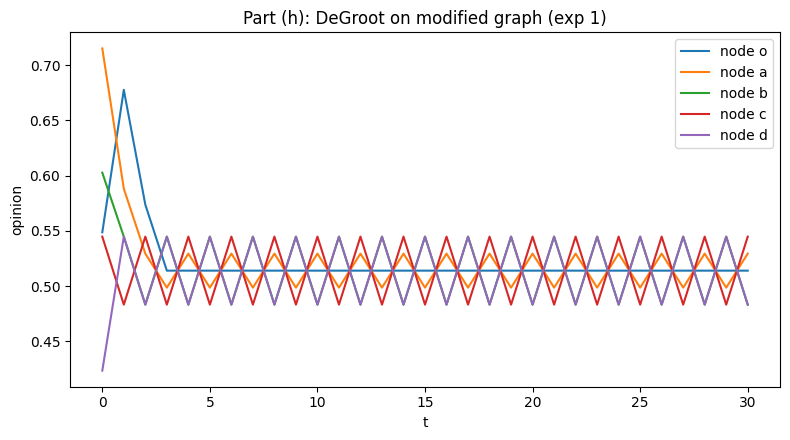


Experiment 2
x(0) = [0.6459 0.4376 0.8918 0.9637 0.3834]
x(T) = [0.7583 0.861  0.5529 0.9637 0.5529]


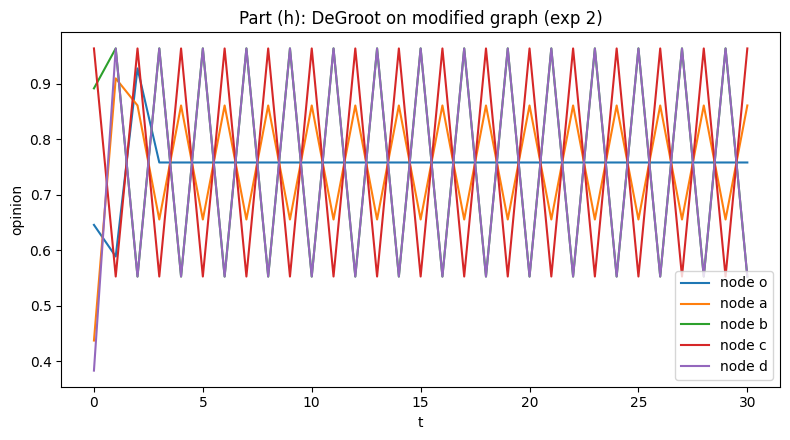


Experiment 3
x(0) = [0.7917 0.5289 0.568  0.9256 0.071 ]
x(T) = [0.5812 0.7534 0.2367 0.9256 0.2367]


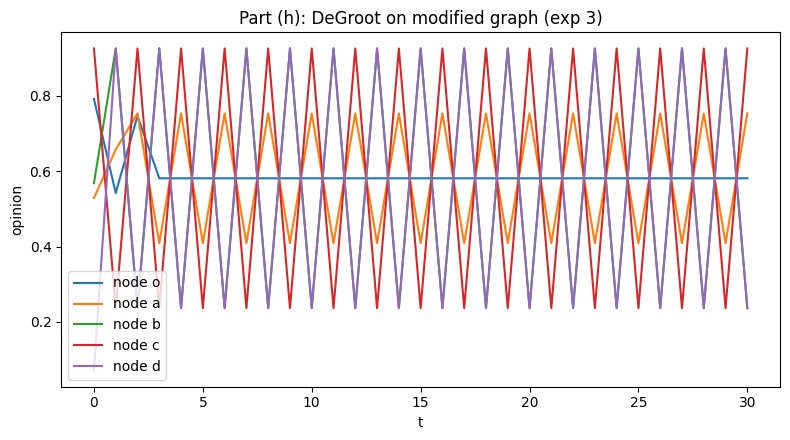


Empirical period-2 check on a longer run:
mean ||x(t+2)-x(t)||_inf (tail) = 0.0
max  ||x(t+2)-x(t)||_inf (tail) = 0.0


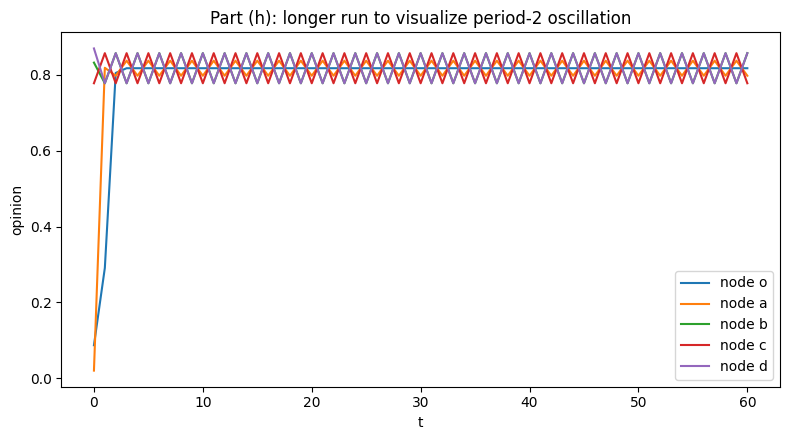

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from math import gcd
from functools import reduce

# Part (h)

nodes = ["o", "a", "b", "c", "d"]
idx = {n:i for i,n in enumerate(nodes)}

# Rate/weight matrix Λ from the statement (rows/cols: o,a,b,c,d)
Lambda = np.array([
    [0.0, 2/5, 1/5, 0.0, 0.0],  # o -> a,b
    [0.0, 0.0, 3/4, 1/4, 0.0],  # a -> b,c
    [1/2, 0.0, 0.0, 1/3, 0.0],  # b -> o,c
    [0.0, 0.0, 1/3, 0.0, 2/3],  # c -> b,d
    [0.0, 1/3, 0.0, 1/3, 0.0],  # d -> a,c
], dtype=float)

def build_P_from_Lambda(L):
    """Build DeGroot P = D^{-1} L (row-stochastic), assuming each row has positive sum."""
    row_sums = L.sum(axis=1)
    if np.any(row_sums <= 0):
        raise ValueError("Some node has zero out-weight; cannot build row-stochastic P without extra convention.")
    D_inv = np.diag(1.0 / row_sums)
    return D_inv @ L

def build_graph_from_Lambda(L):
    """Directed weighted graph from L: edge i->j exists if L_ij > 0 with weight L_ij."""
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for i,u in enumerate(nodes):
        for j,v in enumerate(nodes):
            if L[i,j] > 0:
                G.add_edge(u, v, weight=L[i,j])
    return G

# Remove edges (b,o) and (d,a) from Lambda
Lambda_h = Lambda.copy()
Lambda_h[idx["b"], idx["o"]] = 0.0  # remove (b,o)
Lambda_h[idx["d"], idx["a"]] = 0.0  # remove (d,a)

# Build P^(h)
P_h = build_P_from_Lambda(Lambda_h)

print("P^(h) = D^{-1} Lambda^(h)  (rows: o,a,b,c,d):\n", np.round(P_h, 4))
print("Row sums (should be 1):", np.round(P_h.sum(axis=1), 6))

# Graph + SCC analysis
G_h = build_graph_from_Lambda(Lambda_h)
sccs = list(nx.strongly_connected_components(G_h))
print("\nStrongly Connected Components (SCCs):", sccs)

# condensation graph: nodes are SCCs
C = nx.condensation(G_h, sccs)
sink_components = [c for c in C.nodes() if C.out_degree(c) == 0]
print("Sink SCC indices in condensation graph:", sink_components)

# identify sink SCC node sets
sink_scc_sets = [sccs[k] for k in sink_components]
print("Sink SCC node sets:", sink_scc_sets)

# Periodicity check for the sink SCC (using simple cycle lengths)
# We compute simple cycles in the sink subgraph and take gcd of their lengths.
def period_of_subgraph(G, sub_nodes, max_cycles=2000):
    H = G.subgraph(sub_nodes).copy()
    cycles = []
    # simple_cycles can be expensive, but for 3 nodes it's fine
    for cyc in nx.simple_cycles(H):
        cycles.append(len(cyc))
        if len(cycles) >= max_cycles:
            break
    if len(cycles) == 0:
        return None, []
    per = reduce(gcd, cycles)
    return per, cycles

if len(sink_scc_sets) > 0:
    per, cycles = period_of_subgraph(G_h, list(sink_scc_sets[0]))
    print("\nCycle lengths in sink SCC:", cycles)
    print("gcd(cycle lengths) = period =", per)

# Simulate DeGroot dynamics x(t+1)=P x(t)
def degroot_sim(P, x0, T=30):
    x = np.zeros((len(x0), T+1))
    x[:,0] = x0
    for t in range(T):
        x[:,t+1] = P @ x[:,t]
    return x

def plot_trajectories(x, title):
    plt.figure(figsize=(8,4.5))
    for i,n in enumerate(nodes):
        plt.plot(x[i,:], label=f"node {n}")
    plt.xlabel("t")
    plt.ylabel("opinion")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# run multiple experiments
np.random.seed(0)
T = 30
for exp in range(1, 4):
    x0 = np.random.rand(len(nodes))
    x = degroot_sim(P_h, x0, T=T)
    print(f"\nExperiment {exp}")
    print("x(0) =", np.round(x0, 4))
    print("x(T) =", np.round(x[:,-1], 4))
    plot_trajectories(x, title=f"Part (h): DeGroot on modified graph (exp {exp})")

# Quick empirical check of period-2 oscillation:
# Look at difference between x(t) and x(t+2) in the tail.
def check_period2(x, tail=10, tol=1e-3):
    T = x.shape[1]-1
    start = max(0, T-tail)
    diffs = []
    for t in range(start, T-2):
        diffs.append(np.linalg.norm(x[:,t+2]-x[:,t], ord=np.inf))
    return (np.mean(diffs), np.max(diffs))

x0 = np.random.rand(len(nodes))
x = degroot_sim(P_h, x0, T=60)
mean_d, max_d = check_period2(x, tail=20, tol=1e-3)
print("\nEmpirical period-2 check on a longer run:")
print("mean ||x(t+2)-x(t)||_inf (tail) =", mean_d)
print("max  ||x(t+2)-x(t)||_inf (tail) =", max_d)
plot_trajectories(x, title="Part (h): longer run to visualize period-2 oscillation")


# **Exercise 2**

We consider the closed network defined in Exercise 1 with transition rate matrix:
$$
\Lambda = \begin{pmatrix}
0 & 2/5 & 1/5 & 0 & 0 \\
0 & 0 & 3/4 & 1/4 & 0 \\
1/2 & 0 & 0 & 1/3 & 0 \\
0 & 0 & 1/3 & 0 & 2/3 \\
0 & 1/3 & 0 & 1/3 & 0
\end{pmatrix}
$$

We initialize a population of $N=100$ particles, all starting at node **a** at time $t=0$. The system is closed (no particles enter or leave).

We study the system dynamics from two perspectives:

1.  **Particle Perspective:** We track individual trajectories using the **Uniformization Method** (global Poisson clock with rate $w^* = \max_i w_i$).
2.  **Node Perspective:** We track the aggregate number of particles $N_i(t)$ in each node using the **Gillespie Algorithm**.

The goal is to verify that the macroscopic behavior (node counts) emerges consistently from the microscopic rules (particle random walks).

---

### **Part (a) — Particle Perspective**
- Simulate **100 independent particles** starting at node $a$.
- Record the time it takes for each particle to return to node $a$.
- Compute the **average return time** and compare it to the single-particle result from Exercise 1.

---

### **Part (b) — Node Perspective**
- Simulate the system for **60 time units** tracking $N_i(t)$.
- Plot the number of particles in each node over time.
- Compare the final node counts with the **theoretical stationary distribution** (scaled by $N$).

=== Exercise 2 Results ===
Part A: Average Return Time (N=100): 6.9033
Theoretical Return Time: 6.7083

Part B: Final Node Counts (t=60): [22 16 28 21 13]
Expected Counts (Stationary): [21.74 14.91 26.09 18.63 18.63]

Plot saved as 'node_perspective_simulation.png'


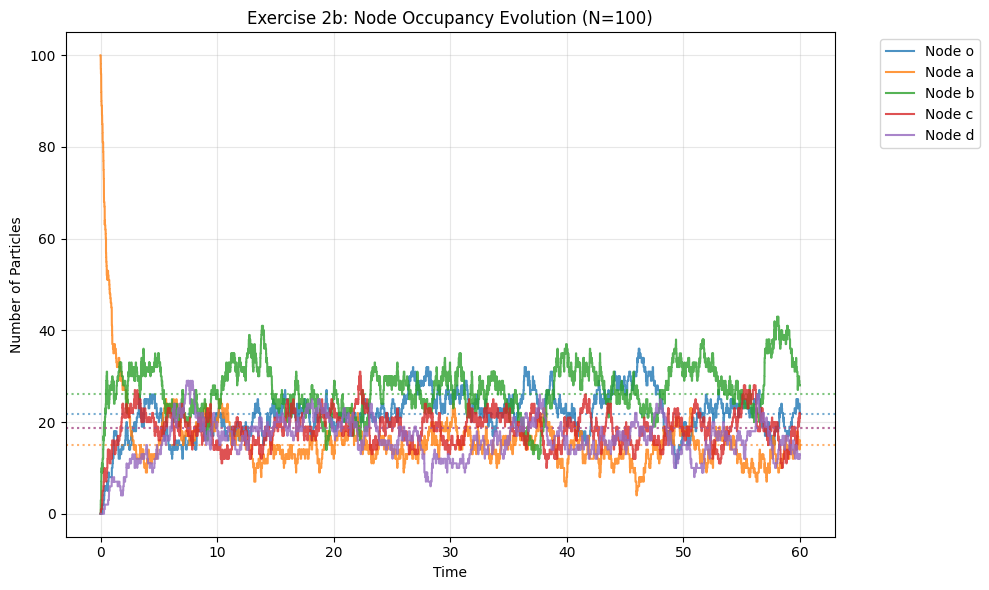

In [14]:
import numpy as np
import matplotlib.pyplot as plt

class NetworkDynamicsSimulation:
    def __init__(self):
        # Define the nodes and mapping
        self.nodes = ['o', 'a', 'b', 'c', 'd']
        self.node_map = {name: i for i, name in enumerate(self.nodes)}
        self.num_nodes = len(self.nodes)

        # Transition Rate Matrix Lambda (same as Exercise 1)
        self.Lambda = np.array([
            [0.0, 2/5, 1/5, 0.0, 0.0],
            [0.0, 0.0, 3/4, 1/4, 0.0],
            [1/2, 0.0, 0.0, 1/3, 0.0],
            [0.0, 0.0, 1/3, 0.0, 2/3],
            [0.0, 1/3, 0.0, 1/3, 0.0]
        ])

        # Calculate total exit rates w_i for each node
        self.w = np.sum(self.Lambda, axis=1)

        # --- Setup for Part A (Uniformization/Jensen's Method) ---
        # Find the max rate w* for the global clock
        self.w_star = np.max(self.w)

        # Create uniformized matrix P_unif = I + Q/w*
        # This adds self-loops to nodes that are slower than w*
        self.P_unif = self.Lambda / self.w_star
        for i in range(self.num_nodes):
            self.P_unif[i, i] += 1.0 - (self.w[i] / self.w_star)

        # --- Setup for Part B (Gillespie SSA) ---
        # Standard embedded chain probabilities (where particle goes when it leaves)
        self.P_embedded = np.zeros_like(self.Lambda)
        for i in range(self.num_nodes):
            if self.w[i] > 0:
                self.P_embedded[i, :] = self.Lambda[i, :] / self.w[i]

    def get_theoretical_stationary(self):
        # Solves pi * Q = 0 to get theoretical stationary distribution
        Q = self.Lambda - np.diag(self.w)
        evals, evecs = np.linalg.eig(Q.T)

        # Get eigenvector for eigenvalue 0
        idx = np.argmin(np.abs(evals))
        pi = np.real(evecs[:, idx])
        return pi / np.sum(pi)

    def solve_particle_perspective(self, n_particles=100, start_node='a'):
        # Part A: Simulate 100 particles using Uniformization
        # This uses the global clock w* as requested
        start_idx = self.node_map[start_node]
        return_times = []

        np.random.seed(42) # For reproducibility

        for k in range(n_particles):
            current_node = start_idx
            time = 0.0

            while True:
                # 1. Sample time from global Poisson clock
                dt = np.random.exponential(1.0 / self.w_star)
                time += dt

                # 2. Move using uniformized matrix (may self-loop)
                probs = self.P_unif[current_node]
                next_node = np.random.choice(self.num_nodes, p=probs)
                current_node = next_node

                # Check if returned to start
                if current_node == start_idx:
                    return_times.append(time)
                    break

        return np.mean(return_times), return_times

    def solve_node_perspective(self, n_particles=100, start_node='a', duration=60.0):
        # Part B: Simulate node counts using Gillespie Algorithm
        # Initial state: all particles at 'a'
        state = np.zeros(self.num_nodes, dtype=int)
        start_idx = self.node_map[start_node]
        state[start_idx] = n_particles

        t = 0.0
        times = [0.0]
        history = [state.copy()]

        np.random.seed(42)

        while t < duration:
            # Calculate total system rate (propensities)
            propensities = state * self.w
            total_rate = np.sum(propensities)

            if total_rate == 0:
                break

            # 1. Sample time to next event
            dt = np.random.exponential(1.0 / total_rate)
            t += dt

            if t > duration:
                times.append(duration)
                history.append(state.copy())
                break

            # 2. Pick source node (who fires?)
            source_probs = propensities / total_rate
            source_node = np.random.choice(self.num_nodes, p=source_probs)

            # 3. Pick target node (where do they go?)
            target_probs = self.P_embedded[source_node]
            target_node = np.random.choice(self.num_nodes, p=target_probs)

            # Update counts
            state[source_node] -= 1
            state[target_node] += 1

            times.append(t)
            history.append(state.copy())

        return times, np.array(history)

    def run_analysis(self):
        print("=== Exercise 2 Results ===")

        # Part A
        avg_ret, _ = self.solve_particle_perspective(n_particles=100)
        print(f"Part A: Average Return Time (N=100): {avg_ret:.4f}")

        # Check against theory
        pi = self.get_theoretical_stationary()
        a_idx = self.node_map['a']
        theo_val = 1.0 / (pi[a_idx] * self.w[a_idx])
        print(f"Theoretical Return Time: {theo_val:.4f}")

        # Part B
        times, history = self.solve_node_perspective(n_particles=100)
        final_counts = history[-1]
        print(f"\nPart B: Final Node Counts (t=60): {final_counts}")
        print(f"Expected Counts (Stationary): {np.round(pi * 100, 2)}")

        # Plotting
        self.plot_results(times, history, pi*100)

    def plot_results(self, times, history, expected_counts):
        plt.figure(figsize=(10, 6))
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

        for i, node in enumerate(self.nodes):
            plt.step(times, history[:, i], where='post', label=f'Node {node}', color=colors[i], alpha=0.8)
            plt.axhline(y=expected_counts[i], color=colors[i], linestyle=':', alpha=0.6)

        plt.title('Exercise 2b: Node Occupancy Evolution (N=100)')
        plt.xlabel('Time')
        plt.ylabel('Number of Particles')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('node_perspective_simulation.png', dpi=300)
        print("\nPlot saved as 'node_perspective_simulation.png'")

if __name__ == "__main__":
    sim = NetworkDynamicsSimulation()
    sim.run_analysis()

# **Exercise 3**


We consider the open network with transition rate matrix  
$$
\Lambda_{open} = \begin{pmatrix}
0 & 1 & 1 & 0 & 0 \\
0 & 0 & 1/4 & 1/4 & 2/4 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0
\end{pmatrix}
$$

Particles enter node **o** according to a Poisson process with rate $\lambda$.  
Each node forwards particles at rates given by $\omega = \Lambda \mathbf{1}$, and $N(t)$ denotes the number of particles in each node at time $t$.

We study two forwarding mechanisms:

1. **Proportional rate:** node $i$ forwards particles with rate $\omega_i N_i(t)$.  
2. **Fixed rate:** node $i$ forwards particles with constant rate $\omega_i$.  

Since node **d** has no outgoing edges, we set $\omega_d = 7/4$ and remove one particle each time its clock ticks.

The goal is to simulate both systems and determine when they remain stable.

---

### **Part (a) — Proportional rate**
- Simulate for **60 time units** with input rate $\lambda = 100$.  
- Plot the number of particles in each node over time.  
- Find the **largest input rate** the system can handle without blowing up.

---

### **Part (b) — Fixed rate**
- Simulate for **6000 time units** with input rate $\lambda = 2$.  
- Plot the number of particles in each node over time.  
- Determine the **maximum stable input rate** and justify your conclusion.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Nodes: o, a, b, c, d
NODES = ["o", "a", "b", "c", "d"]
NUM_NODES = len(NODES)

# Transition rate matrix Λ_open
Lambda_open = np.array([
    [0.0, 1.0,   1.0,   0.0, 0.0],     # o
    [0.0, 0.0,   1/4,   1/4, 2/4],     # a
    [0.0, 0.0,   0.0,   1.0, 0.0],     # b
    [0.0, 0.0,   0.0,   0.0, 1.0],     # c
    [0.0, 0.0,   0.0,   0.0, 0.0],     # d (sink)
])

# Service/clock rates ω_i.
# For nodes with outgoing edges, use row-sum of Λ.
# For sink d, the statement says omega_d = 7/4.
omega = np.sum(Lambda_open, axis=1)
omega[-1] = 7/4  # sink clock rate

# Routing matrix P (row-stochastic on nodes with outgoing edges)
# P = diag(omega)^(-1) Λ  (then renormalize nonzero rows)
P = np.linalg.inv(np.diag(omega)) @ Lambda_open
for i in range(NUM_NODES):
    row_sum = P[i, :].sum()
    if row_sum > 0:
        P[i, :] /= row_sum


In [16]:
#  utilities
def compute_next_event_times(lmbda_in, node_occupancy, mode="proportional"):

    rates = np.zeros(NUM_NODES + 1)

    if mode == "proportional":
        # each particle has its own clock; node i total rate = omega_i * N_i(t)
        rates[:-1] = omega * node_occupancy
    elif mode == "fixed":
        # node i has a single clock at rate omega_i (if node empty, events do nothing)
        rates[:-1] = omega
    else:
        raise ValueError("mode must be 'proportional' or 'fixed'")

    rates[-1] = lmbda_in  # exogenous arrivals into node o

    # exponential waiting times; if rate==0 -> time=+inf
    times = np.full(NUM_NODES + 1, np.inf)
    for k, r in enumerate(rates):
        if r > 0:
            times[k] = -np.log(np.random.rand()) / r
    return times


def simulate_network(lmbda_in, total_time, mode="proportional", random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)

    occ = np.zeros(NUM_NODES, dtype=int)
    t = 0.0

    times = [t]
    occs = [occ.copy()]

    while t < total_time:
        next_times = compute_next_event_times(lmbda_in, occ, mode)
        j = int(np.argmin(next_times))
        dt = float(next_times[j])

        if not np.isfinite(dt):
            # no events can happen anymore
            break

        t += dt

        receiver = None

        if j < NUM_NODES:
            # Node clock tick
            if occ[j] > 0:
                if j == NUM_NODES - 1:
                    # d: particle leaves system
                    occ[j] -= 1
                else:
                    # remove one particle from j and send it to a neighbor by routing P[j,:]
                    receiver = np.random.choice(NUM_NODES, p=P[j, :])
                    occ[j] -= 1
        else:
            # External arrival to node o
            receiver = 0

        if receiver is not None:
            occ[receiver] += 1

        times.append(t)
        occs.append(occ.copy())

    return np.array(times), np.vstack(occs)


def plot_trajectories(times, occ, title):
    plt.figure(figsize=(8, 4.2))
    for i, node in enumerate(NODES):
        plt.plot(times, occ[:, i], label=node, lw=1)
    plt.xlabel("time")
    plt.ylabel("number of particles")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def stability_flag(times, occ, mode, tail_frac=0.25, slope_tol=1e-3):

    if mode == "proportional":
        return True

    total = occ.sum(axis=1).astype(float)
    if len(total) < 10:
        return True

    m = max(5, int(np.floor(tail_frac * len(total))))
    t_tail = times[-m:]
    y_tail = total[-m:]

    # Linear fit slope on tail
    t0 = t_tail[0]
    x = t_tail - t0
    A = np.vstack([x, np.ones_like(x)]).T
    slope, _ = np.linalg.lstsq(A, y_tail, rcond=None)[0]

    # If slope significantly positive => unstable (growing)
    return slope <= slope_tol


def run_and_summarize(lam, T, mode, seed=0, do_plot=False):
    t, occ = simulate_network(lam, T, mode=mode, random_seed=seed)
    final_vec = occ[-1, :]
    final_total = int(final_vec.sum())
    stable = stability_flag(t, occ, mode=mode)

    if do_plot:
        plot_trajectories(t, occ, f"{mode.capitalize()} rate, λ={lam}, T={T}")

    return {
        "lambda": float(lam),
        "stable": bool(stable),
        "final_total": final_total,
        "final_by_node": {NODES[i]: int(final_vec[i]) for i in range(NUM_NODES)},
        "times": t,
        "occ": occ,
    }


def scan_lambdas(lambda_list, T, mode, seed=1):

    results = []
    print(f"\n SCAN ({mode})  T={T} ")
    header = "λ".ljust(10) + "stable".ljust(10) + "final_total".ljust(14) + "final_by_node (o,a,b,c,d)"
    print(header)
    print("_" * len(header))

    for lam in lambda_list:
        r = run_and_summarize(lam, T, mode=mode, seed=seed, do_plot=False)
        fb = r["final_by_node"]
        row = (
            f"{r['lambda']:<10.4g}"
            f"{str(r['stable']):<10}"
            f"{r['final_total']:<14d}"
            f"({fb['o']},{fb['a']},{fb['b']},{fb['c']},{fb['d']})"
        )
        print(row)
        results.append(r)

    return results


# Fixed-rate theoretical flow balance

def fixed_rate_flow_balance(lam):

    flows = {
        "o->a": lam/2,
        "o->b": lam/2,
        "a->b": lam/8,
        "a->c": lam/8,
        "a->d": lam/4,
        "b->c": 5*lam/8,
        "c->d": 3*lam/4,
        "out(d)": lam,  # equals total input at steady state (if stable)
    }
    node_in = {
        "o": lam,
        "a": lam/2,
        "b": 5*lam/8,
        "c": 3*lam/4,
        "d": lam
    }
    # stability capacity constraints (fixed):
    caps = {"o": 2.0, "a": 1.0, "b": 1.0, "c": 1.0, "d": 7/4}
    ratios = {k: node_in[k]/caps[k] for k in caps}

    return flows, node_in, caps, ratios



def fixed_rate_lambda_max_from_balance():
    # effective arrival rates into nodes are:
    # o: 1 * λ
    # a: (1/2) * λ
    # b: (5/8) * λ
    # c: (3/4) * λ
    # d: 1 * λ
    coeff = {"o": 1.0, "a": 0.5, "b": 5/8, "c": 3/4, "d": 1.0}
    caps  = {"o": 2.0, "a": 1.0, "b": 1.0, "c": 1.0, "d": 7/4}

    bounds = {node: caps[node] / coeff[node] for node in coeff}
    lam_star = min(bounds.values())
    bottleneck = min(bounds, key=bounds.get)

    return lam_star, bottleneck, bounds




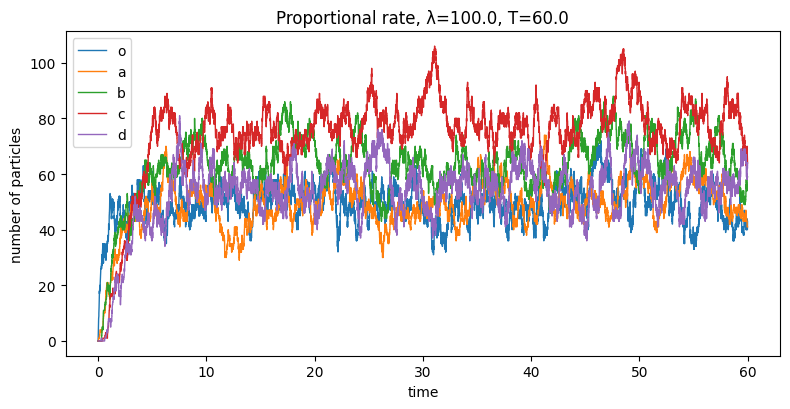


[Part a] Proportional-rate (single run)
Final particle distribution: {'o': 43, 'a': 41, 'b': 59, 'c': 64, 'd': 64}
Total final particles: 271
Stable: True

 SCAN (proportional)  T=60.0 
λ         stable    final_total   final_by_node (o,a,b,c,d)
___________________________________________________________
100       True      315           (48,55,72,83,57)
120       True      363           (61,71,83,82,66)
150       True      473           (74,87,101,133,78)
200       True      629           (111,108,146,139,125)
500       True      1454          (253,270,331,328,272)
700       True      2073          (355,347,456,529,386)
1000      True      2924          (501,504,603,726,590)
1500      True      4595          (825,774,940,1130,926)
2000      True      5904          (1020,944,1294,1506,1140)
5000      True      14801         (2447,2505,3028,3907,2914)


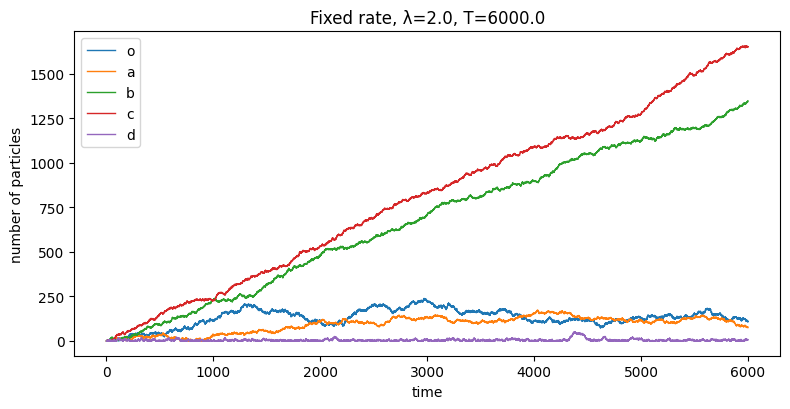


[Part b] Fixed-rate (single run)
Final particle distribution: {'o': 108, 'a': 75, 'b': 1347, 'c': 1650, 'd': 6}
Total final particles: 3186
Stable: False

[Fixed] From flow-balance analysis (computed in code):
  λ_max = 1.3333333333333333
  bottleneck node = c
  bounds = {'o': 2.0, 'a': 2.0, 'b': 1.6, 'c': 1.3333333333333333, 'd': 1.75}

Flow balance at steady state (as functions of λ, evaluated at λ=λ_max):
  o->a   = 0.666667
  o->b   = 0.666667
  a->b   = 0.166667
  a->c   = 0.166667
  a->d   = 0.333333
  b->c   = 0.833333
  c->d   = 1
  out(d) = 1.33333

Effective arrival rates into nodes (evaluated at λ=λ_max) and utilization:
  node o:  in=1.33333  cap=2  util=0.666667
  node a:  in=0.666667  cap=1  util=0.666667
  node b:  in=0.833333  cap=1  util=0.833333
  node c:  in=1  cap=1  util=1
  node d:  in=1.33333  cap=1.75  util=0.761905

 SCAN (fixed)  T=6000.0 
λ         stable    final_total   final_by_node (o,a,b,c,d)
___________________________________________________________
0

In [17]:
# simulation

if __name__ == "__main__":

    ############# Part (a) Proportional rate ################
    T_prop = 60.0

    # Single run requested in exercise
    lam_prop_main = 100.0
    r_prop = run_and_summarize(lam_prop_main, T_prop, mode="proportional", seed=0, do_plot=True)

    print("\n[Part a] Proportional-rate (single run)")
    print("Final particle distribution:", r_prop["final_by_node"])
    print("Total final particles:", r_prop["final_total"])
    print("Stable:", r_prop["stable"])

    lambda_list_prop = [100, 120, 150, 200, 500,700, 1000, 1500, 2000, 5000]
    prop_scan = scan_lambdas(lambda_list_prop, T_prop, mode="proportional", seed=1)

    ########### Part (b) Fixed rate #################

    T_fix = 6000.0

    lam_fix_main = 2.0
    r_fix = run_and_summarize(lam_fix_main, T_fix, mode="fixed", seed=0, do_plot=True)

    print("\n[Part b] Fixed-rate (single run)")
    print("Final particle distribution:", r_fix["final_by_node"])
    print("Total final particles:", r_fix["final_total"])
    print("Stable:", r_fix["stable"])

    lam_star, bottleneck, bounds = fixed_rate_lambda_max_from_balance()
    print("\n[Fixed] From flow-balance analysis (computed in code):")
    print("  λ_max =", lam_star)
    print("  bottleneck node =", bottleneck)
    print("  bounds =", bounds)


    flows, node_in, caps, ratios = fixed_rate_flow_balance(lam_star)
    print("\nFlow balance at steady state (as functions of λ, evaluated at λ=λ_max):")
    for k in ["o->a","o->b","a->b","a->c","a->d","b->c","c->d","out(d)"]:
        print(f"  {k:6s} = {flows[k]:.6g}")

    print("\nEffective arrival rates into nodes (evaluated at λ=λ_max) and utilization:")
    for node in ["o","a","b","c","d"]:
        print(f"  node {node}:  in={node_in[node]:.6g}  cap={caps[node]:.6g}  util={ratios[node]:.6g}")

    # Scan λ list around the stability boundary
    lambda_list_fix = [0.5, 1.0, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.5, 1.75, 2.0]
    fix_scan = scan_lambdas(lambda_list_fix, T_fix, mode="fixed", seed=1)




last_stable = None
first_unstable = None

for r in fix_scan:
    if r["stable"]:
        last_stable = r["lambda"]
    elif first_unstable is None:
        first_unstable = r["lambda"]

print("\n[Fixed] From simulation scan:")
print("  last stable λ =", last_stable)
print("  first unstable λ =", first_unstable)
